# Exploratory Data Analysis

This notebook explores the cleaned Online Retail II dataset
to understand sales patterns, customer behavior, products,
countries, and transaction trends.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/online_retail_cleaned.csv")

In [4]:
df.shape

(779425, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 95.2 MB


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [7]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [8]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [9]:
df[["Quantity", "Price", "TotalAmount"]].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [10]:
df["TotalAmount"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

In [11]:
df["TotalAmount"].sum()

np.float64(17374804.268)

In [12]:
df["Customer ID"].nunique()

5878

In [13]:
df["StockCode"].nunique()

4631

In [14]:
df["Country"].nunique()

41

In [15]:
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalAmount, dtype: float64

In [16]:
product_sales = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

product_sales.head(10)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalAmount, dtype: float64

In [17]:
customer_sales = (
    df.groupby("Customer ID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

customer_sales.describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: TotalAmount, dtype: float64

In [18]:
customer_transactions = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

customer_transactions.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

In [19]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [20]:
monthly_sales = (
    df.groupby("YearMonth")["TotalAmount"]
      .sum()
)

monthly_sales

YearMonth
2009-12     683504.010
2010-01     555802.672
2010-02     504558.956
2010-03     696978.471
2010-04     591982.002
2010-05     597833.380
2010-06     636371.130
2010-07     589736.170
2010-08     602224.600
2010-09     829013.951
2010-10    1033112.010
2010-11    1166460.022
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Freq: M, Name: TotalAmount, dtype: float64

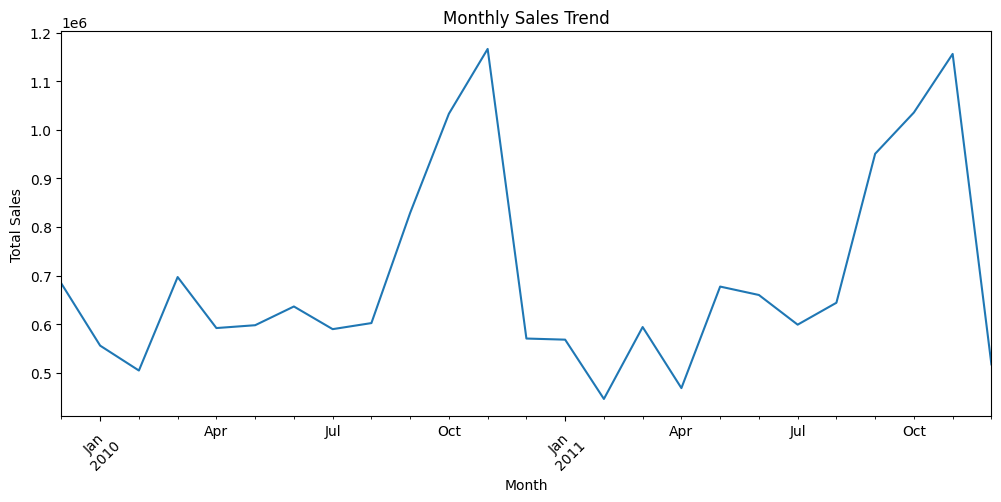

In [21]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## EDA Findings

The exploratory analysis provided the following observations:

- The cleaned dataset contains 779,425 transaction lines from 5,878 unique customers.
- The dataset contains 4,631 unique products across 41 countries.
- Total sales value across the cleaned transaction data is approximately 17.37 million.
- The United Kingdom accounts for the largest share of sales among the countries in the dataset.
- Customer spending is highly uneven, with a relatively small number of customers generating very high sales values.
- Customer purchase frequency also varies considerably, with many customers having relatively few invoices while some customers purchase repeatedly.
- Monthly sales show higher sales activity during several later-year months, particularly around September to November.
- These observations provide the foundation for customer-level RFM analysis and segmentation.